# Bayesian Optimization for Buchwald-Hartwig Reaction
In this Lab session, we will use BO to optimize a chemical reaction, the Buchwald-Hartwig (BH) reaction. The BH reaction is a palladium-catalyzed cross-coupling that forms C–N bonds between an aryl (or heteroaryl) halide and an amine.

We will explore combinations of reaction conditions to achieve high reaction yield.

The new Python package that we use in this lab is `scikit-optimize`, a tool-kit for ML optimization: [Website](https://scikit-optimize.github.io/stable/).

Install: `pip install scikit-optimize`

Import: `import skopt`

### First, fetch the dataset

In [1]:
!mkdir -p lab12/
!wget -q -O lab12/bh_reactions.csv "https://github.com/SunLab-Rutgers/chem542_CDS/raw/main/labs/lab12/data/bh_reactions.csv"

### Install and Import Python libraries used in this lab

In [2]:
!pip install -q scikit-optimize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 4.6 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from skopt import gp_minimize
from skopt.space import Integer
import matplotlib.pyplot as plt

### Load the csv file

In [4]:
df = pd.read_csv("lab12/bh_reactions.csv", index_col=False)
df.head()

,reaction,ligand,additive,base,aryl halide,product,rxn,yield
0,0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C(C)(C)C)...,C1(N(CC2=CC=CC=C2)CC3=CC=CC=C3)=CC=NO1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,IC1=CC=C(CC)C=C1,CCc1ccc(Nc2ccc(C)cc2)cc1,CCc1ccc(I)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2ccc...,21.400068
1,0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C3CCCCC3)...,CC1=NOC=C1,CN1CCCN2C1=NCCC2,ClC1=CC=C(CC)C=C1,CCc1ccc(Nc2ccc(C)cc2)cc1,CCc1ccc(Cl)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2cc...,1.922792
2,0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C(C)(C)C)...,O=C(OC)C1=CC=NO1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,BrC1=CC=C(CC)C=C1,CCc1ccc(Nc2ccc(C)cc2)cc1,CCc1ccc(Br)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2cc...,15.673040
3,0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P([C@@]3(C[...,CC1=CC=NO1,CN1CCCN2C1=NCCC2,IC1=CC=C(CC)C=C1,CCc1ccc(Nc2ccc(C)cc2)cc1,CCc1ccc(I)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2ccc...,76.225051
4,0,CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C3CCCCC3)...,C1(C2=CC=CC=C2)=CON=C1,CN(C)P(N(C)C)(N(C)C)=NP(N(C)C)(N(C)C)=NCC,IC1=CC=C(CC)C=C1,CCc1ccc(Nc2ccc(C)cc2)cc1,CCc1ccc(I)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2ccc...,15.011788


### Explanation of the columns
| Column          | Description |
|-----------------|-------------|
| `reaction`      | Reaction identifier: 0,1,2,3,4; used for bookkeeping or indexing; not used as a model input. |
| `ligand`        | Phosphine ligand coordinated to the Pd catalyst: SMILES string. |
| `additive`      | Optional additive included in the reaction (e.g., salts, acids): SMILES string. |
| `base`          | Base used to deprotonate the amine: SMILES string. |
| `aryl halide`   | Aryl or heteroaryl electrophile, the reactant: SMILES string. |
| `product`       | Coupled aryl amine product: SMILES string. Usually excluded from model inputs to avoid information leakage. |
| `rxn`           | Encoded reaction string: Reaction String (similar to SMILES string). Used for traceability and linking to raw experimental records. |
| `yield`         | Experimental reaction yield: percentage. This is the **target function** $f(\mathbf{x})$ optimized in Bayesian optimization. |

### We will only use the reaction 0 in this dataset

In [5]:
reaction_idx = 0
df_react = df[df['reaction'] == reaction_idx]

### Extract the columns for reaction conditions

In [7]:
categorical_cols = ['ligand','additive','base','aryl halide','product']
features = df_react[categorical_cols]
y = df_react['yield'].values
n_samples = len(y)
print(f"Exploring {n_samples} instances.")
print(f"The maximum yield possible: {max(y)}%")

Exploring 790 instances.
The maximum yield possible: 86.59757822%


### We simply use one-hot encoding to encode the features
In the next lecture, we will talk about reaction fingerprints.

In [8]:
# One-hot encode categorical variables
encoder = OneHotEncoder(sparse_output=False)  # use sparse_output=False to return dense numpy array
X = encoder.fit_transform(features)

### Rescale the feature matrix

In [9]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## BO Setup
#### First, we define the target function. Since the BO optimization from `scikit-optimize` performs **minimization**, we take the negative value of the yield as the target function

In [10]:
def target_function(idx):
    '''
    skopt set idx to be a numpy array of shape (1,), e.g. np.array([1]).
    '''
    idx = int(idx[0])
    return -y[idx]

### Next, we define the search space, which is the 790 reactions we previously selected.

Note that we pretend that we do not know the yield :)

In [12]:
search_space = [Integer(0, n_samples - 1, name='reaction_idx')] # name is some label you assign

#### We randomly pick the initial experiments to run

In [13]:
n_initial = 10 # number of initial experiments

## Run BO

In [14]:
result = gp_minimize(
    func=target_function, # target function
    dimensions=search_space, # search space
    n_calls=100, # number of BO iterations
    n_initial_points=n_initial, # number of initial experiments
    acq_func='EI',  # acquisition function, expected improvement (EI)
    # random_state=0
)

/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(703)] before, using random point [np.int64(1)]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(789)] before, using random point [np.int64(245)]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(789)] before, using random point [np.int64(618)]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(789)] before, using random point [np.int64(491)]
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/skopt/optimizer/optimizer.py:517: UserWarning: The objective has been evaluated at point [np.int64(789)] before, using random point [np.int64(

## Extract the result

In [15]:
best_idx = int(result.x[0])
print("Best reaction found:")
print(df_react.iloc[best_idx])
print("Yield:", y[best_idx])

Best reaction found:
reaction                                                       0
ligand         CC(C)C(C=C(C(C)C)C=C1C(C)C)=C1C2=C(P(C(C)(C)C)...
additive                                  C1(C2=CC=CC=C2)=CC=NO1
base                                            CN1CCCN2C1=NCCC2
aryl halide                                    BrC1=CC=C(CC)C=C1
product                                 CCc1ccc(Nc2ccc(C)cc2)cc1
rxn            CCc1ccc(Br)cc1.Cc1ccc(N)cc1.O=S(=O)(O[Pd]1c2cc...
yield                                                  81.569431
Name: 570, dtype: object
Yield: 81.56943098


## Plot the progress

We plot two values:

(1) The target function value of the newly added point at each iteration

(2) The **best so far** value of the target function.

Note that because the acquisition function EI balances the target function value and the variance, sometimes the next BO step might not beat the previous step.

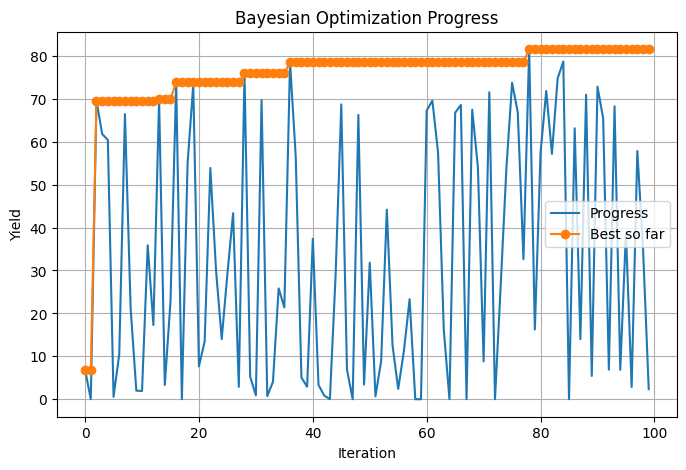

In [16]:
best_so_far = -np.minimum.accumulate(result.func_vals) #result.func_vals is an array of all function values evaluated during BO; computes the cumulative minimum along the array
plt.figure(figsize=(8,5))
plt.plot(-result.func_vals, label='Progress')
plt.plot(best_so_far, label='Best so far', marker='o')
plt.xlabel('Iteration')
plt.ylabel('Yield')
plt.title('Bayesian Optimization Progress')
plt.legend()
plt.grid(True)

### Let's read the explicit loop from another course
https://zzhenglab.github.io/ai4chem/lecture-14.html